# Propuesta 1
## Autor: Yasin Hanin Boukaddidi


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("tcga_simple_train.csv")
texts = df['text']
lables = df['t']

# Preprocesamiento de los textos

In [ ]:
%%capture
# Solución al error de compatibilidad: instalar una versión de spaCy compatible con scispacy 0.5.4
!pip install spacy==3.7.4 scispacy
!pip install https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_core_sci_sm-0.5.4.tar.gz

In [ ]:
import scispacy
import spacy

nlp = spacy.load("en_core_sci_sm")

/usr/local/lib/python3.12/dist-packages/spacy/language.py:2195: FutureWarning: Possible set union at position 6328
  deserializers["tokenizer"] = lambda p: self.tokenizer.from_disk(  # type: ignore[union-attr]


In [ ]:
texts[0]

In [ ]:
# Ejemplo rápido con un texto del dataset
doc = nlp(texts[0])
print(f"Entidades encontradas en el primer reporte: {doc.ents}")

Entidades encontradas en el primer reporte: (Date, Recelpt, Clinical Diagnosis, Specimens, Kidney, Left Upper Pole, Partial Nephrectomy, DIAGNOSIS, Kidney, Left Upper Pole, Partial Nephrectomy, Tumor Type, Renal cell carcinoma, Conventional, Fuhrman Nuclear Grade, Nuclear grade II/IV., Tumor Size, Greatest, diameter, Local Invasion, renal cortical types, Renal Vein, Surgical Margins, Free of tumor, Non-Neoplastic Kidney, focal, chronic inflammation, focal superficial glomerulosclerosis, Adrenal Gland, Lymph Nodes, Staging, renal cell carcinoma/oncocytoma, pT1 Tumor, dimension, kidney, IHAVE, REVIEWED, REPORT, Gross Description, specimen, fresh, frozen section, consultation, labeled, left upper, deep margin, wedge, portion, kidney, suture, deep margin, perirenal, container, aggregate, unremarkable, fibroadipose tissue, margin, black, specimen, well-circumscribed, cortically, focally hemorrhagic, tumor, tumor, renal parenchyma, no. extension, perirenal fat, clearance, resection margin, s

### También se hace una lemmatización

In [ ]:
# Optimizamos el procesamiento usando nlp.pipe y desactivando componentes innecesarios
processed_texts = []

# 'disable' evita cargar módulos pesados que no usamos para la lematización
# 'n_process=-1' usa todos los núcleos disponibles (útil en máquinas con múltiples CPUs)
for doc in nlp.pipe(texts.astype(str), batch_size=50, disable=["parser", "ner"]):
    tokens = [tok.lemma_ for tok in doc if not tok.is_stop and not tok.is_punct]
    processed_texts.append(tokens)

texts = pd.Series(processed_texts)
print("Procesamiento completado con éxito.")

Procesamiento completado con éxito.


# Modelos

In [ ]:
models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'SVM': SVC(kernel='linear')
}

## Con Pesado Binario

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score

# Función para que CountVectorizer acepte la lista de tokens directamente
def identity_tokenizer(text):
    return text

# 70 % train
X_train, X_temp, y_train, y_temp = train_test_split(texts, lables, test_size=0.30, random_state=42)

# 15 % val, 15 % test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Tamaño Entrenamiento: {len(X_train)}")
print(f"Tamaño Validación: {len(X_val)}")
print(f"Tamaño Prueba: {len(X_test)}")



# Almacenamiento de métricas
val_f1 = {}
test_f1 = {}

for name, model in models.items():
    # Ajustamos CountVectorizer para no procesar strings, sino usar los tokens existentes
    pipeline = Pipeline([
        ('bow', CountVectorizer(tokenizer=identity_tokenizer, preprocessor=identity_tokenizer, binary=True, token_pattern=None, lowercase=False)),
        ('clf', model)
    ])

    pipeline.fit(X_train, y_train)

    # Evaluación en validación
    val_preds = pipeline.predict(X_val)
    val_f1[name] = f1_score(y_val, val_preds, average='macro')

    # Evaluación final en test
    test_preds = pipeline.predict(X_test)
    test_f1[name] = f1_score(y_test, test_preds, average='macro')

    print(f"{name} -> Val Macro F1: {val_f1[name]:.4f} | Test Macro F1: {test_f1[name]:.4f}")

Tamaño Entrenamiento: 3610
Tamaño Validación: 774
Tamaño Prueba: 774
Naive Bayes -> Val Macro F1: 0.5442 | Test Macro F1: 0.5505
Logistic Regression -> Val Macro F1: 0.6800 | Test Macro F1: 0.6896
SVM -> Val Macro F1: 0.6114 | Test Macro F1: 0.6474


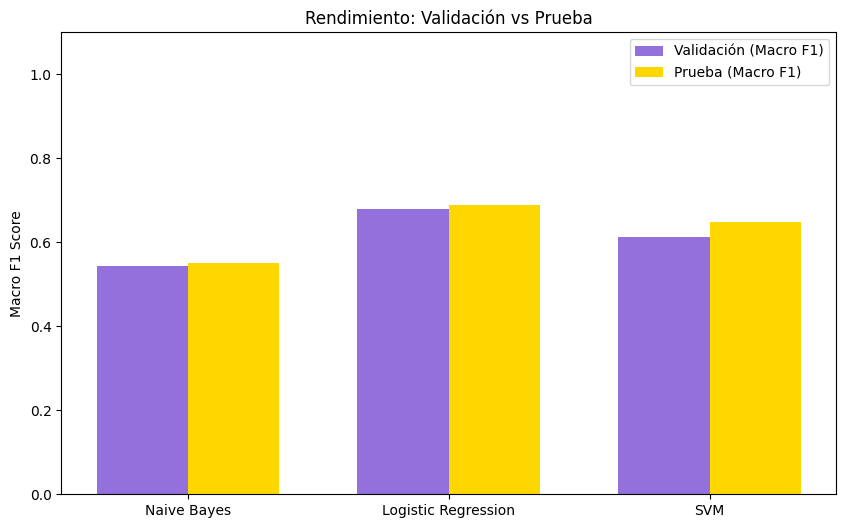

In [ ]:
# Comparativa entre Validación y Prueba
import matplotlib.pyplot as plt
import numpy as np

names = list(val_f1.keys())
val_values = list(val_f1.values())
test_values = list(test_f1.values())

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, val_values, width, label='Validación (Macro F1)', color='mediumpurple')
ax.bar(x + width/2, test_values, width, label='Prueba (Macro F1)', color='gold')

ax.set_ylabel('Macro F1 Score')
ax.set_title('Rendimiento: Validación vs Prueba')
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylim(0, 1.1)
ax.legend()

plt.show()

## Con TF-IDF

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score

# Función para que el vectorizador acepte la lista de tokens directamente
def identity_tokenizer(text):
    return text

# 70 % train
X_train, X_temp, y_train, y_temp = train_test_split(texts, lables, test_size=0.30, random_state=42)

# 15 % val, 15 % test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)


# Almacenamiento de métricas
val_f1 = {}
test_f1 = {}

for name, model in models.items():
    # Configuración de Pipeline con TF-IDF corregido
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(tokenizer=identity_tokenizer, preprocessor=identity_tokenizer, token_pattern=None, lowercase=False)),
        ('clf', model)
    ])

    pipeline.fit(X_train, y_train)

    # Evaluación en validación
    val_preds = pipeline.predict(X_val)
    val_f1[name] = f1_score(y_val, val_preds, average='macro')

    # Evaluación final en test
    test_preds = pipeline.predict(X_test)
    test_f1[name] = f1_score(y_test, test_preds, average='macro')

    print(f"{name} (TF-IDF) -> Val Macro F1: {val_f1[name]:.4f} | Test Macro F1: {test_f1[name]:.4f}")

Naive Bayes (TF-IDF) -> Val Macro F1: 0.4037 | Test Macro F1: 0.4212
Logistic Regression (TF-IDF) -> Val Macro F1: 0.6197 | Test Macro F1: 0.6090
SVM (TF-IDF) -> Val Macro F1: 0.6120 | Test Macro F1: 0.6259


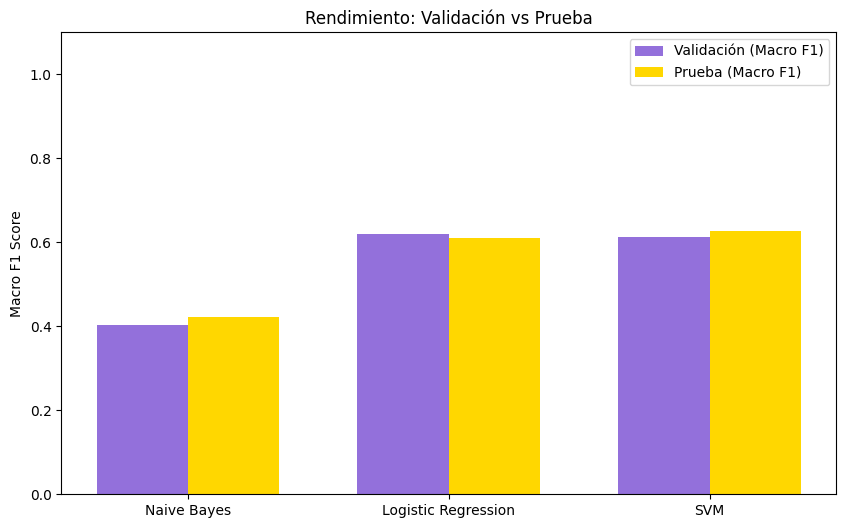

In [ ]:
# Comparativa entre Validación y Prueba
import matplotlib.pyplot as plt
import numpy as np

names = list(val_f1.keys())
val_values = list(val_f1.values())
test_values = list(test_f1.values())

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, val_values, width, label='Validación (Macro F1)', color='mediumpurple')
ax.bar(x + width/2, test_values, width, label='Prueba (Macro F1)', color='gold')

ax.set_ylabel('Macro F1 Score')
ax.set_title('Rendimiento: Validación vs Prueba')
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylim(0, 1.1)
ax.legend()

plt.show()

### Comparativa: CountVectorizer vs TF-IDF
Visualización del impacto de la estrategia de vectorización en el rendimiento de los modelos (en el conjunto de Validación).

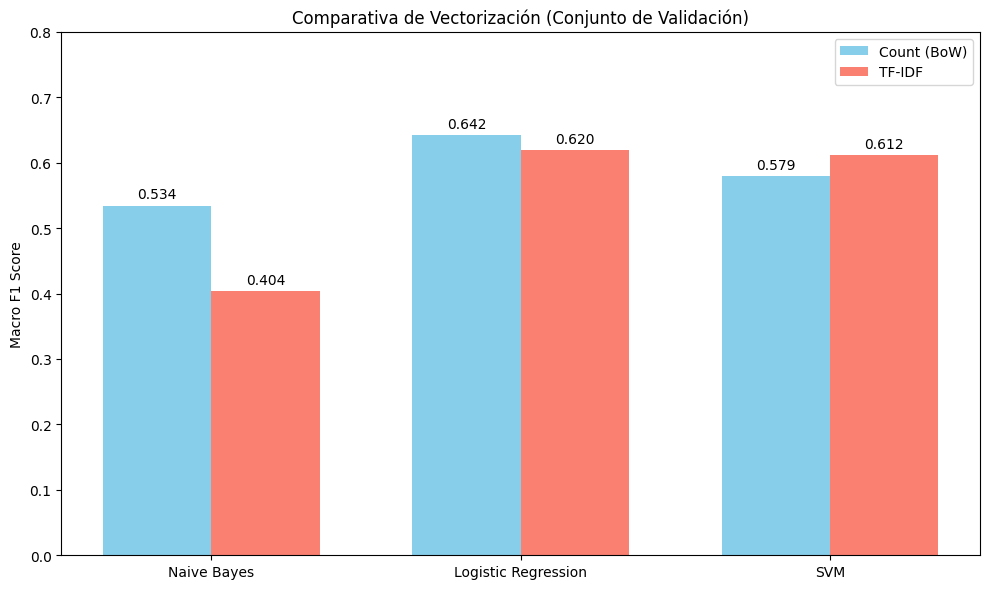

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Datos extraídos de los experimentos previos
labels = ['Naive Bayes', 'Logistic Regression', 'SVM']
bow_scores = [0.5345, 0.6425, 0.5793]
tfidf_scores = [0.4037, 0.6197, 0.6120]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, bow_scores, width, label='Count (BoW)', color='skyblue')
rects2 = ax.bar(x + width/2, tfidf_scores, width, label='TF-IDF', color='salmon')

ax.set_ylabel('Macro F1 Score')
ax.set_title('Comparativa de Vectorización (Conjunto de Validación)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 0.8)
ax.legend()

# Añadir etiquetas de valor sobre las barras
ax.bar_label(rects1, padding=3, fmt='%.3f')
ax.bar_label(rects2, padding=3, fmt='%.3f')

fig.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Crear un DataFrame con los resultados de validación
resultados_data = {
    'Modelo': ['Naive Bayes', 'Logistic Regression', 'SVM'],
    'Macro F1 (BoW)': [0.5345, 0.6425, 0.5793],
    'Macro F1 (TF-IDF)': [0.4037, 0.6197, 0.6120]
}

df_resultados = pd.DataFrame(resultados_data)

# Resaltar el valor máximo para cada método
display(df_resultados.style.highlight_max(subset=['Macro F1 (BoW)', 'Macro F1 (TF-IDF)'], color='lightgreen', axis=0))

,Modelo,Macro F1 (BoW),Macro F1 (TF-IDF)
0,Naive Bayes,0.534500,0.403700
1,Logistic Regression,0.642500,0.619700
2,SVM,0.579300,0.612000
